# Cardiovascular Disease Prediction



##  1.Import Libraries

In [51]:
# Import basic libraries for data handling
import pandas as pd          # used for working with datasets (DataFrame)
import numpy as np           # used for numerical operations

# Import libraries for visualization
import matplotlib.pyplot as plt   # for plotting graphs
import seaborn as sns             # for better visualization

# Import libraries for machine learning
from sklearn.model_selection import train_test_split   # to split data
from sklearn.preprocessing import StandardScaler       # to scale data
from sklearn.linear_model import LogisticRegression    # ML model

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve

##  2. Load Dataset

In [52]:
# Import Google Drive module from Google Colab
from google.colab import drive

# Mount Google Drive to access files from Colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/data set!!/cardio_data_processed.csv')

In [54]:

# Show first 5 rows to understand data
df.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


##  3.Data Understanding

In [55]:
# Check number of rows and columns
print("Shape of dataset:", df.shape)

# Check data types of each column
print("\nData Types:\n", df.dtypes)

# Get statistical summary (mean, std, min, max)
print("\nSummary Statistics:\n", df.describe())

# Check if there are missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape of dataset: (68205, 17)

Data Types:
 id                       int64
age                      int64
gender                   int64
height                   int64
weight                 float64
ap_hi                    int64
ap_lo                    int64
cholesterol              int64
gluc                     int64
smoke                    int64
alco                     int64
active                   int64
cardio                   int64
age_years                int64
bmi                    float64
bp_category             object
bp_category_encoded     object
dtype: object

Summary Statistics:
                  id           age        gender        height        weight  \
count  68205.000000  68205.000000  68205.000000  68205.000000  68205.000000   
mean   49972.410498  19462.667737      1.348625    164.372861     74.100688   
std    28852.138290   2468.381854      0.476539      8.176756     14.288862   
min        0.000000  10798.000000      1.000000     55.000000     11.000000  

## 4.Exploratory Data Analysis (EDA)

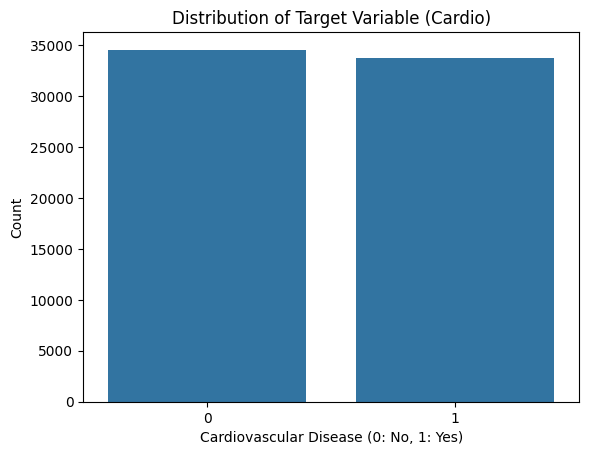

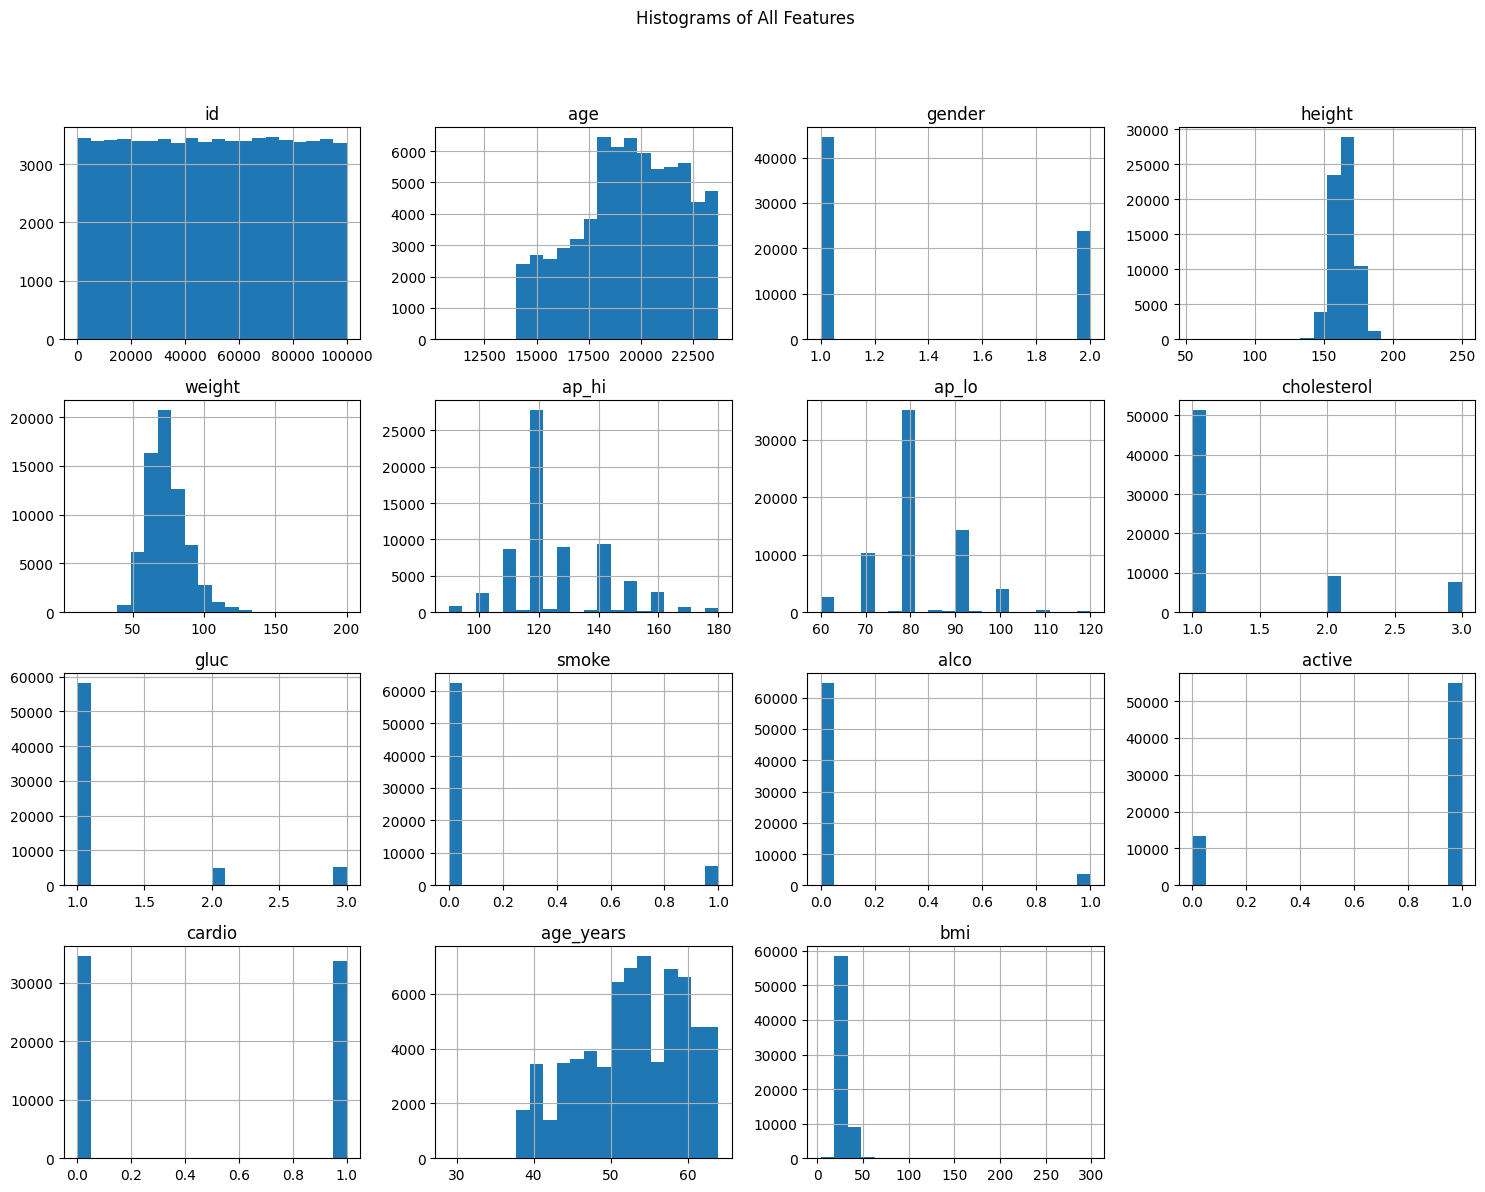

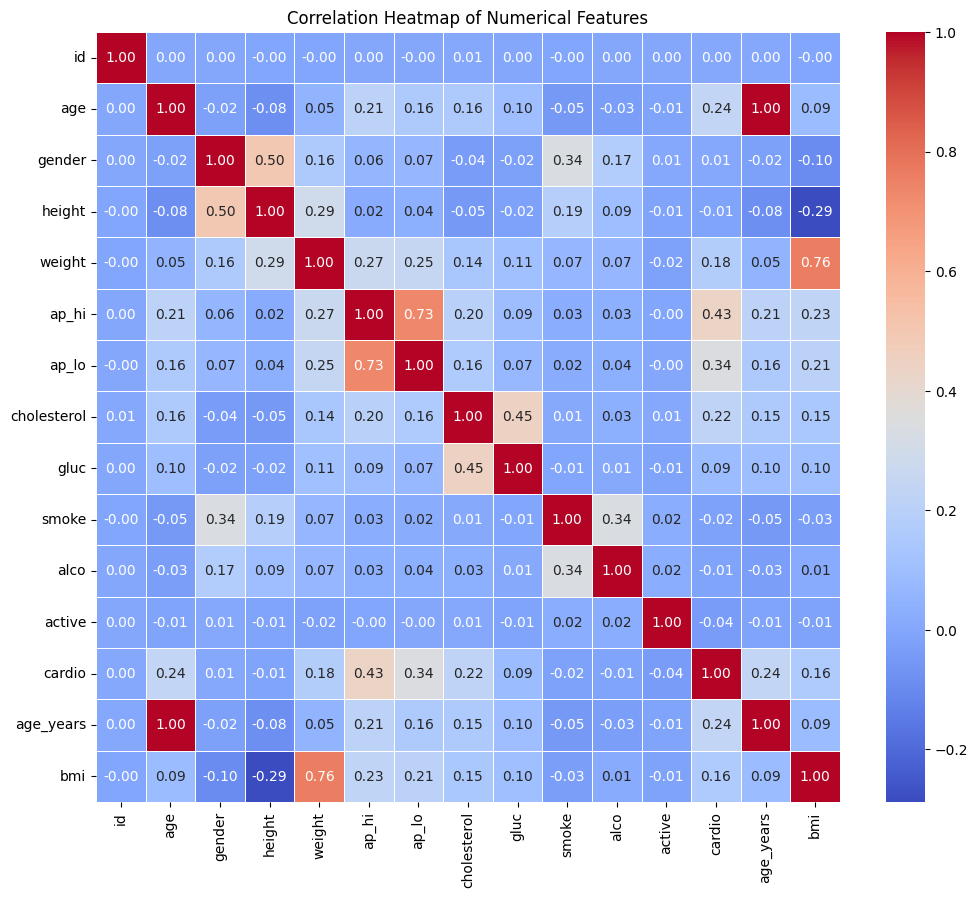

In [56]:
# Count plot of the target variable 'cardio'
# This plot shows the distribution of individuals with and without cardiovascular disease.
sns.countplot(x='cardio', data=df)
plt.title("Distribution of Target Variable (Cardio)")
plt.xlabel("Cardiovascular Disease (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()

# Histograms of all numerical features
# These plots display the distribution of each numerical feature, helping to understand their ranges, skewness, and potential outliers.
df.hist(figsize=(15,12), bins=20) # Increased figure size for better readability and added bins
plt.suptitle("Histograms of All Features", y=1.02) # Add a main title for all histograms
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent titles from overlapping
plt.show()

# Correlation heatmap for numerical features
# This heatmap visualizes the Pearson correlation coefficients between all pairs of numerical features.
# It helps identify linear relationships, with values close to 1 indicating strong positive correlation.
# -1 indicating strong negative correlation, and 0 indicating no linear correlation.
# Only numerical columns are selected to avoid errors with string data.
plt.figure(figsize=(12,10)) # Adjusted figure size for better visualization
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

##  5. Data Preprocessing

In [57]:
# Fill missing values with mean (simple method)
# This line is commented out because df.isnull().sum() showed no missing values,
# and attempting to fill NA with mean caused a TypeError on string columns.
# df.fillna(df.mean(), inplace=True)

# Separate features (X) from the target variable (y)
X = df.drop('cardio', axis=1)

# The target variable is 'cardio'
y = df['cardio']

# Select only numerical columns from X for scaling
# StandardScaler expects numerical input, so non-numeric columns must be excluded.
X_numerical = X.select_dtypes(include=np.number)

# Initialize StandardScaler to standardize features
# Standardization scales features to have a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()

# Fit the scaler to the numerical features and transform them
X_scaled = scaler.fit_transform(X_numerical)

## 6. Train-Test Split

In [58]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

##  7. Model Building(Logistic Regression)

In [59]:
# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

##  8. Model Evaluation

In [60]:
# Print all evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7245803093614838
Precision: 0.7489775051124744
Recall: 0.6580326396167091
F1 Score: 0.7005658723200765
ROC-AUC Score: 0.7873473860774975


##  9. Confusion Matrix

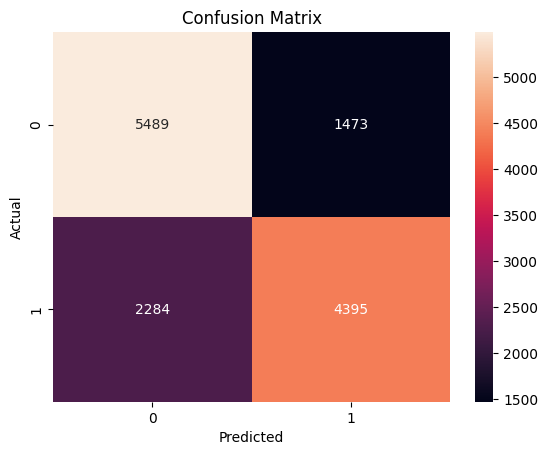

In [61]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  10. ROC Curve

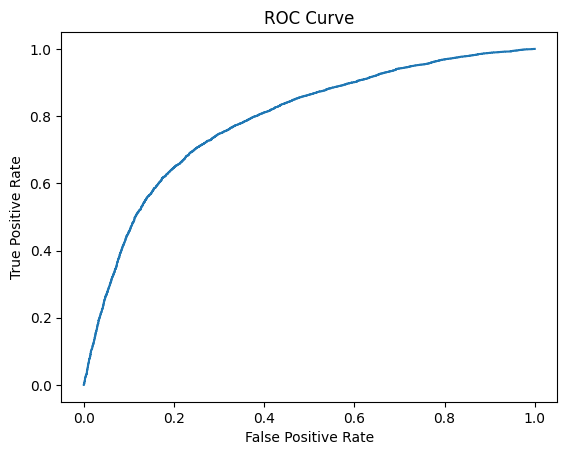

In [62]:
# Calculate ROC curve values
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## 11.Feature Importance analysis (for Decision Tree model)

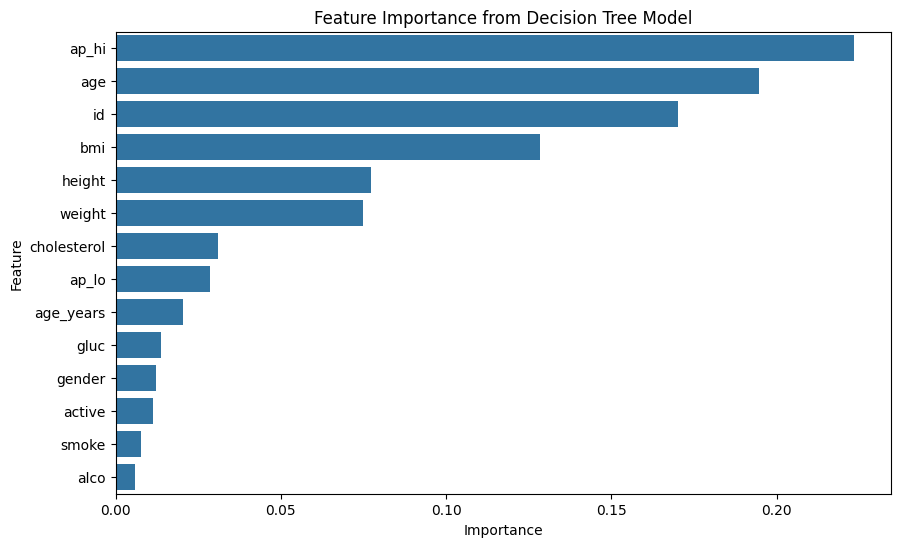

In [63]:
# Import Decision Tree model for feature importance analysis.
from sklearn.tree import DecisionTreeClassifier


# Create a Decision Tree classifier model.
# The `random_state` parameter ensures reproducibility of the results.
dt_model = DecisionTreeClassifier(random_state=42)


# Train the Decision Tree model using the scaled training data.
# X_train contains the standardized numerical features, and y_train is the target variable.
dt_model.fit(X_train, y_train)


# Make predictions on the test set using the trained Decision Tree model.
dt_pred = dt_model.predict(X_test)


# Predict probabilities for the positive class (cardio=1) on the test set.
# This is used later for calculating the ROC-AUC score.
dt_prob = dt_model.predict_proba(X_test)[:,1]


# Extract feature importance values from the trained Decision Tree model.
# These values indicate the relative importance of each feature in predicting the target variable.
importance = dt_model.feature_importances_


# Create a Pandas DataFrame to store feature names and their corresponding importance scores.
# We use `X_numerical.columns` to get the names of the numerical features that the model was trained on.
feature_importance = pd.DataFrame({
    'Feature': X_numerical.columns,
    'Importance': importance
})


# Sort the features by their importance in descending order.
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)


# Plot a horizontal bar chart to visualize the feature importances.
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

# Add a title to the plot for clarity.
plt.title("Feature Importance from Decision Tree Model")

# Display the plot.
plt.show()

The feature importance graph shows which variables have the strongest impact on predicting cardiovascular disease.

Features with higher importance values contribute more to the model's decision-making process.